In [4]:
import pandas as pd
import numpy as np


In [5]:
from google.colab import files

uploaded = files.upload()

df = pd.read_excel(next(iter(uploaded)))

print(df.head())


Saving Dataset.xlsx to Dataset (1).xlsx
   Year  January  February  March  April   May  June  July  August  September  \
0  2021     4207      4000   4431   4395  4249  4157  4918    4569       4811   
1  2022     3097      2771   3981   4717  5291  4987  4949    5144       5285   
2  2023     5396      4690   5798   6163  6054  6001  6103    6089       6201   
3  2024     5989      5241   6478   6724  6097  6063  6392    6856       6722   
4  2025     6332      5811   7290   6674  6808  7318  6851    7598       8117   

   October  November  December      Type  
0     4177      3887      3710  Injuries  
1     5686      5021      5062  Injuries  
2     6723      6156      5642  Injuries  
3     7155      6245      6400  Injuries  
4     8245      7162      6347  Injuries  


In [6]:
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

long_df = df.melt(
    id_vars=["Year", "Type"],
    value_vars=months,
    var_name="Month",
    value_name="Value"
)

long_df["Date"] = pd.to_datetime(
    long_df["Year"].astype(str) + "-" + long_df["Month"] + "-01"
)

long_df = long_df.sort_values(["Type", "Date"])

print(long_df.head())


    Year   Type     Month  Value       Date
5   2021  Death   January    468 2021-01-01
15  2021  Death  February    485 2021-02-01
25  2021  Death     March    565 2021-03-01
35  2021  Death     April    613 2021-04-01
45  2021  Death       May    680 2021-05-01


In [7]:
seasonal_naive = long_df[
    long_df["Year"] == 2024
].copy()

# Move dates from 2024 to 2025
seasonal_naive["Date"] = seasonal_naive["Date"] + pd.DateOffset(years=1)

# Put Injuries and Death into columns
seasonal_naive = seasonal_naive.pivot(
    index="Date",
    columns="Type",
    values="Value"
)

print("2025 Seasonal Naïve Forecast:")
print(seasonal_naive)


2025 Seasonal Naïve Forecast:
Type        Death  Injuries
Date                       
2025-01-01    407      5989
2025-02-01    394      5241
2025-03-01    491      6478
2025-04-01    527      6724
2025-05-01    410      6097
2025-06-01    471      6063
2025-07-01    442      6392
2025-08-01    444      6856
2025-09-01    420      6722
2025-10-01    439      7155
2025-11-01    384      6245
2025-12-01    431      6400


In [8]:
actual_2025 = long_df[
    long_df["Year"] == 2025
].pivot(
    index="Date",
    columns="Type",
    values="Value"
)

print("Actual 2025:")
print(actual_2025)


Actual 2025:
Type        Death  Injuries
Date                       
2025-01-01    407      6332
2025-02-01    423      5811
2025-03-01    583      7290
2025-04-01    502      6674
2025-05-01    466      6808
2025-06-01    483      7318
2025-07-01    407      6851
2025-08-01    482      7598
2025-09-01    509      8117
2025-10-01    575      8245
2025-11-01    504      7162
2025-12-01    488      6347


In [9]:
comparison = pd.DataFrame({
    "Actual_Injuries": actual_2025["Injuries"],
    "Naive_Injuries": seasonal_naive["Injuries"],
    "Actual_Death": actual_2025["Death"],
    "Naive_Death": seasonal_naive["Death"]
})

print(comparison.round(0))


            Actual_Injuries  Naive_Injuries  Actual_Death  Naive_Death
Date                                                                  
2025-01-01             6332            5989           407          407
2025-02-01             5811            5241           423          394
2025-03-01             7290            6478           583          491
2025-04-01             6674            6724           502          527
2025-05-01             6808            6097           466          410
2025-06-01             7318            6063           483          471
2025-07-01             6851            6392           407          442
2025-08-01             7598            6856           482          444
2025-09-01             8117            6722           509          420
2025-10-01             8245            7155           575          439
2025-11-01             7162            6245           504          384
2025-12-01             6347            6400           488          431


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return mae, rmse, mape

# Injuries
mae_i, rmse_i, mape_i = calculate_metrics(
    comparison["Actual_Injuries"],
    comparison["Naive_Injuries"]
)

# Death
mae_d, rmse_d, mape_d = calculate_metrics(
    comparison["Actual_Death"],
    comparison["Naive_Death"]
)

print("===== SEASONAL NAIVE - INJURIES =====")
print("MAE :", round(mae_i, 2))
print("RMSE:", round(rmse_i, 2))
print("MAPE:", round(mape_i, 2), "%")

print("\n===== SEASONAL NAIVE - DEATH =====")
print("MAE :", round(mae_d, 2))
print("RMSE:", round(rmse_d, 2))
print("MAPE:", round(mape_d, 2), "%")
accuracy_i = 100 - mape_i
accuracy_d = 100 - mape_d

print("===== SEASONAL NAIVE ACCURACY =====")
print("Injuries Accuracy:", round(accuracy_i, 2), "%")
print("Death Accuracy   :", round(accuracy_d, 2), "%")


===== SEASONAL NAIVE - INJURIES =====
MAE : 699.75
RMSE: 812.61
MAPE: 9.6 %

===== SEASONAL NAIVE - DEATH =====
MAE : 57.42
RMSE: 70.68
MAPE: 11.27 %
===== SEASONAL NAIVE ACCURACY =====
Injuries Accuracy: 90.4 %
Death Accuracy   : 88.73 %


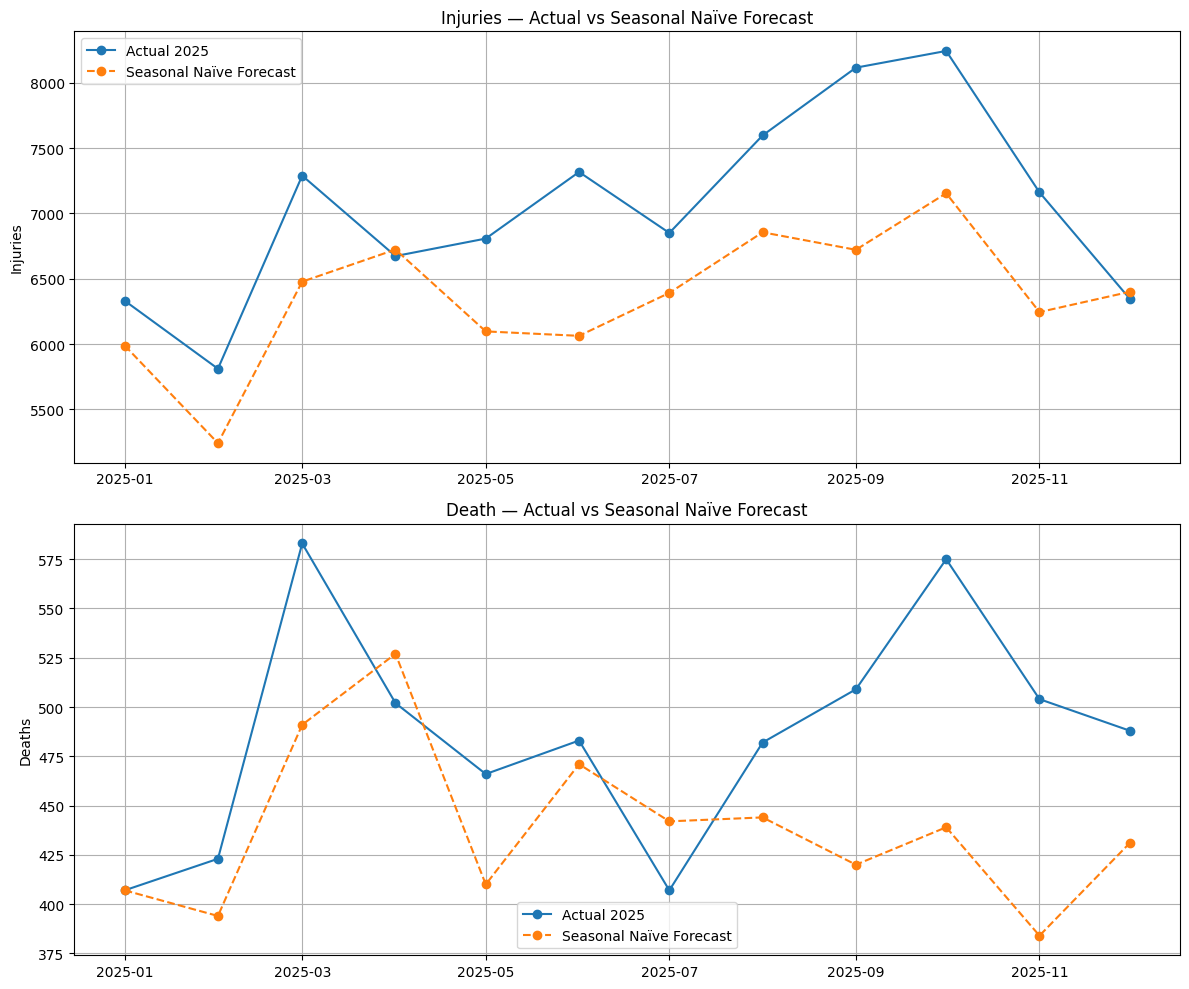

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(
    comparison.index,
    comparison["Actual_Injuries"],
    marker="o",
    label="Actual 2025"
)

axes[0].plot(
    comparison.index,
    comparison["Naive_Injuries"],
    marker="o",
    linestyle="--",
    label="Seasonal Naïve Forecast"
)

axes[0].set_title("Injuries — Actual vs Seasonal Naïve Forecast")
axes[0].set_ylabel("Injuries")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    comparison.index,
    comparison["Actual_Death"],
    marker="o",
    label="Actual 2025"
)

axes[1].plot(
    comparison.index,
    comparison["Naive_Death"],
    marker="o",
    linestyle="--",
    label="Seasonal Naïve Forecast"
)

axes[1].set_title("Death — Actual vs Seasonal Naïve Forecast")
axes[1].set_ylabel("Deaths")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
